# 06 - Model Evaluation

Deep-dive evaluation of the winning model: metrics in business terms, confusion matrix, ROC/PR curves, cross-validation stability, and SHAP-based explainability.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
%matplotlib inline
from train_model import run_training
from evaluation import evaluate_model, get_roc_curve_data, get_pr_curve_data

results = run_training()
best_name = results['best_name']
model = results['results'][best_name]['model']
X_train, X_test = results['X_train'], results['X_test']
y_train, y_test = results['y_train'], results['y_test']
metrics = evaluate_model(model, X_test, y_test)
print('Best model:', best_name)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-07-07 08:14:09,512 | INFO | Logistic Regression: Test AUC=0.7835 | CV AUC=0.7880 +/- 0.0118


2026-07-07 08:14:09,725 | INFO | Decision Tree: Test AUC=0.7522 | CV AUC=0.7494 +/- 0.0104


2026-07-07 08:14:21,868 | INFO | Random Forest: Test AUC=0.7707 | CV AUC=0.7771 +/- 0.0115


2026-07-07 08:14:29,849 | INFO | Gradient Boosting: Test AUC=0.7801 | CV AUC=0.7840 +/- 0.0105


...

2026-07-07 08:15:08,656 | INFO | Saved object to /home/claude/churn/models/trained_model.pkl


2026-07-07 08:15:08,658 | INFO | Saved object to /home/claude/churn/models/feature_scaler.pkl


2026-07-07 08:15:08,661 | INFO | Saved object to /home/claude/churn/models/label_encoders.pkl


2026-07-07 08:15:08,662 | INFO | Saved object to /home/claude/churn/models/model_metadata.pkl


Best model: Logistic Regression


## Classification metrics, explained in business terms

In [2]:
print(f"Accuracy:  {metrics['accuracy']*100:.1f}% — overall correct predictions")
print(f"Precision: {metrics['precision']*100:.1f}% — of customers flagged as churn risks, this % actually churn (controls wasted retention offers)")
print(f"Recall:    {metrics['recall']*100:.1f}% — of customers who actually churned, this % were caught in advance (controls missed saves)")
print(f"F1 Score:  {metrics['f1_score']*100:.1f}% — balance of precision and recall")
print(f"ROC-AUC:   {metrics['roc_auc']*100:.1f}% — how well the model ranks churners above non-churners across all thresholds")

Accuracy:  74.5% — overall correct predictions
Precision: 63.4% — of customers flagged as churn risks, this % actually churn (controls wasted retention offers)
Recall:    46.2% — of customers who actually churned, this % were caught in advance (controls missed saves)
F1 Score:  53.5% — balance of precision and recall
ROC-AUC:   78.4% — how well the model ranks churners above non-churners across all thresholds


## Confusion matrix

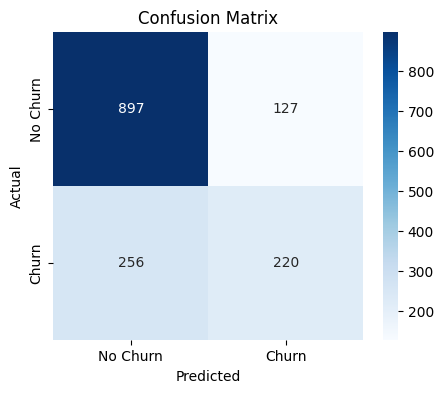

              precision    recall  f1-score   support

    No Churn       0.78      0.88      0.82      1024
       Churn       0.63      0.46      0.53       476

    accuracy                           0.74      1500
   macro avg       0.71      0.67      0.68      1500
weighted avg       0.73      0.74      0.73      1500



In [3]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
ax.set_title('Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.show()
print(metrics['classification_report'])

**Business read:** The model correctly identifies roughly half of true churners at the default 0.5 threshold. Because a missed churner (false negative) usually costs more than a wasted retention offer (false positive), the business can lower the decision threshold to trade some precision for higher recall — a tuning knob documented in `reports/Model_Evaluation.md`.

## ROC and Precision-Recall curves

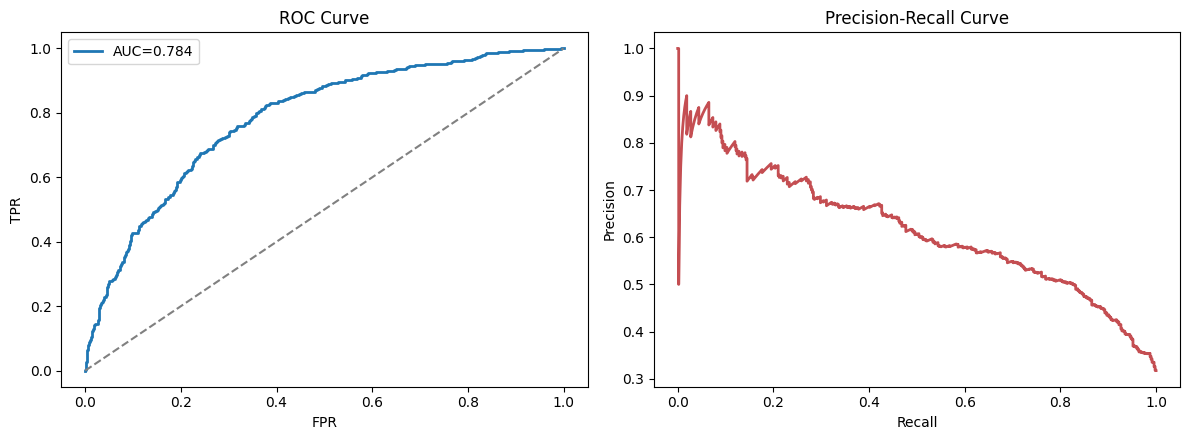

In [4]:
fpr, tpr, _ = get_roc_curve_data(model, X_test, y_test)
precision, recall, _ = get_pr_curve_data(model, X_test, y_test)
fig, axes = plt.subplots(1,2, figsize=(12,4.5))
axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC={metrics['roc_auc']:.3f}")
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
axes[1].plot(recall, precision, linewidth=2, color='#C44E52')
axes[1].set_title('Precision-Recall Curve'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
plt.tight_layout(); plt.show()

## Cross-validation stability across all 8 models

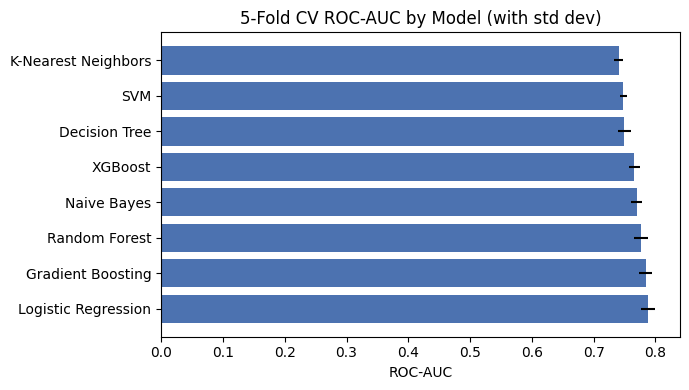

In [5]:
rows = [{'Model': n, 'CV_AUC_Mean': r['cv_auc_mean'], 'CV_AUC_Std': r['cv_auc_std']} for n, r in results['results'].items()]
cv_df = pd.DataFrame(rows).sort_values('CV_AUC_Mean', ascending=False)
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(cv_df['Model'], cv_df['CV_AUC_Mean'], xerr=cv_df['CV_AUC_Std'], color='#4C72B0')
ax.set_title('5-Fold CV ROC-AUC by Model (with std dev)'); ax.set_xlabel('ROC-AUC')
plt.tight_layout(); plt.show()

**Insight:** Low standard deviation (~0.01) across folds for the top models confirms performance is stable and not a fluke of the train/test split.

## Feature importance (Random Forest, for interpretability of non-linear model)

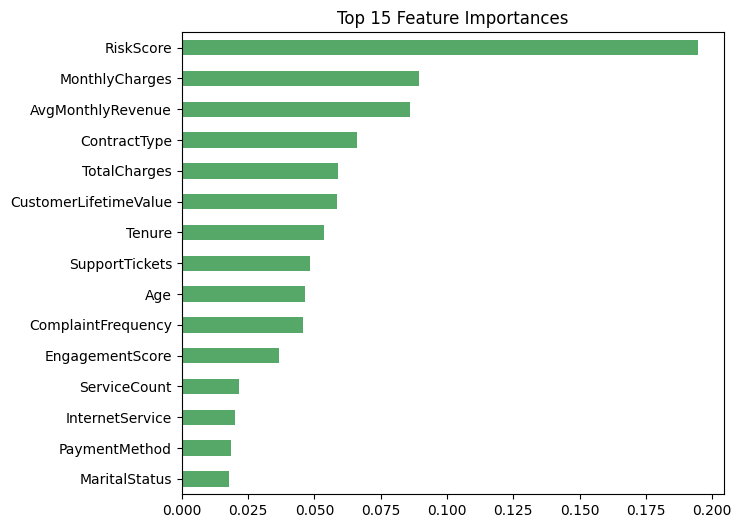

RiskScore                0.194813
MonthlyCharges           0.089652
AvgMonthlyRevenue        0.085981
ContractType             0.065906
TotalCharges             0.058749
CustomerLifetimeValue    0.058723
Tenure                   0.053810
SupportTickets           0.048271
Age                      0.046512
ComplaintFrequency       0.045878
dtype: float64

In [6]:
rf = results['results']['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,6))
importances.head(15).sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Top 15 Feature Importances'); plt.show()
importances.head(10)

## SHAP explainability for the winning (Logistic Regression) model

2026-07-07 08:15:09,711 | WARNING | Background dataset has 6000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=6000 when initializing the masker.


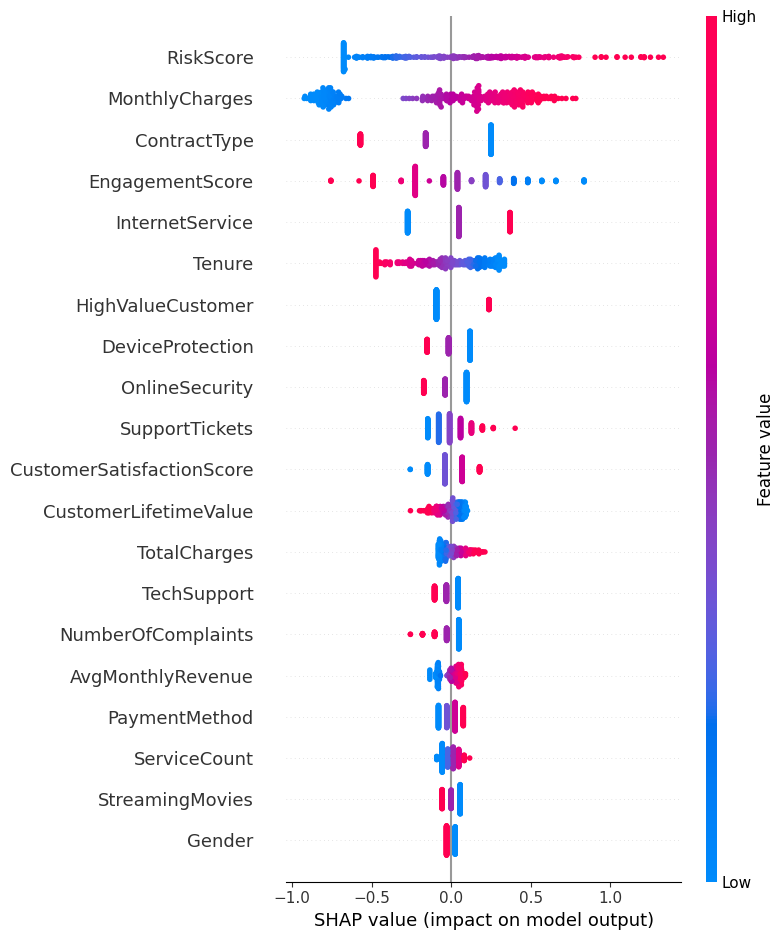

In [7]:
explainer = shap.LinearExplainer(model, X_train)
sample = X_test.sample(300, random_state=1)
shap_values = explainer(sample)
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout(); plt.savefig('../images/plots/shap_summary.png', bbox_inches='tight'); plt.show()

**Insight:** SHAP confirms the same top drivers found in EDA and feature importance — RiskScore, MonthlyCharges, ContractType, and complaint-related features push predictions toward churn, while Tenure and add-on services push away from it. This consistency across three independent methods (EDA, tree importance, SHAP) gives strong confidence the model has learned real business patterns rather than noise.